# Customer Segmentation using K-Means Clustering

## Synent Technologies Internship - Task 6

### Objective
Segment mall customers into different groups using K-Means Clustering to identify customer behavior patterns.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

### Tasks Performed
- Data Cleaning
- Exploratory Data Analysis
- Correlation Analysis
- Elbow Method
- K-Means Clustering
- Cluster Visualization
- Customer Segmentation
- Business Insight Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

## Dataset Preview

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Shape

In [4]:
df.shape

(200, 5)

## Column Names

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


## Missing Values

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

## Removing Duplicate Records

In [9]:
df = df.drop_duplicates()

## Summary Statistics

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Gender Distribution

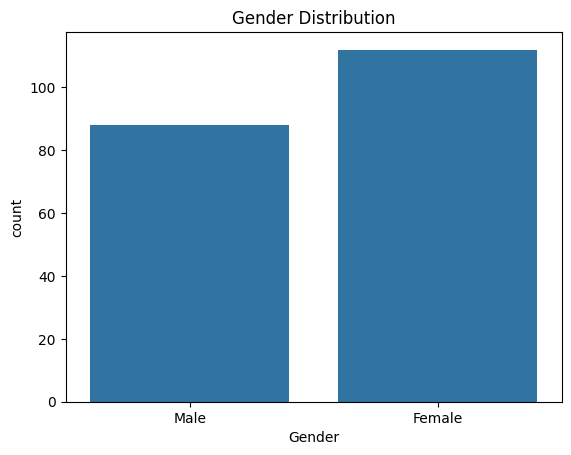

In [11]:
sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")

plt.show()

## Age Distribution

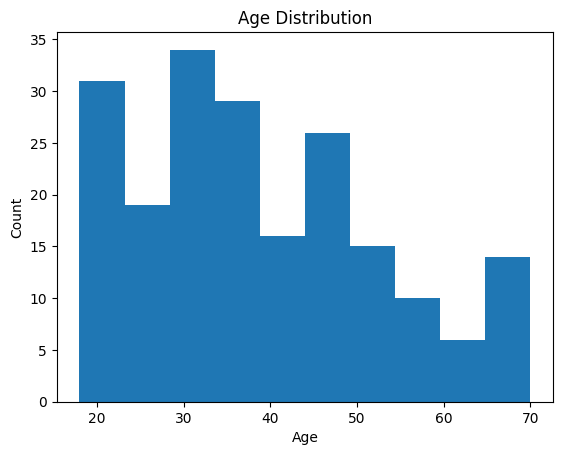

In [12]:
plt.hist(df["Age"])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

## Annual Income Distribution

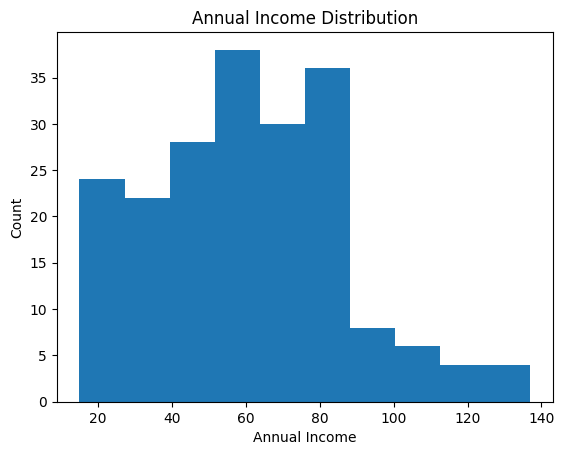

In [13]:
plt.hist(
    df["Annual Income (k$)"]
)

plt.title(
    "Annual Income Distribution"
)

plt.xlabel("Annual Income")

plt.ylabel("Count")

plt.show()

## Spending Score Distribution

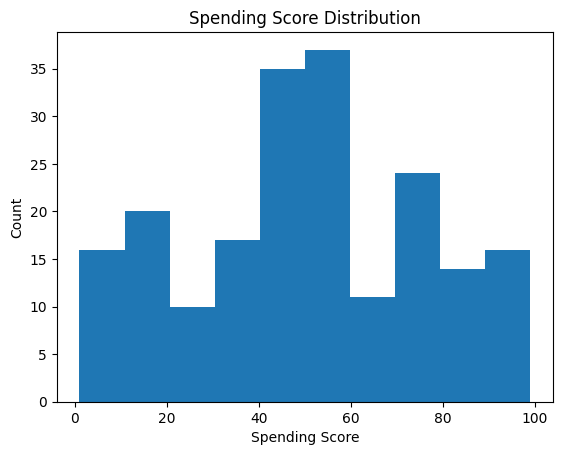

In [14]:
plt.hist(
    df["Spending Score (1-100)"]
)

plt.title(
    "Spending Score Distribution"
)

plt.xlabel("Spending Score")

plt.ylabel("Count")

plt.show()

## Age vs Spending Score

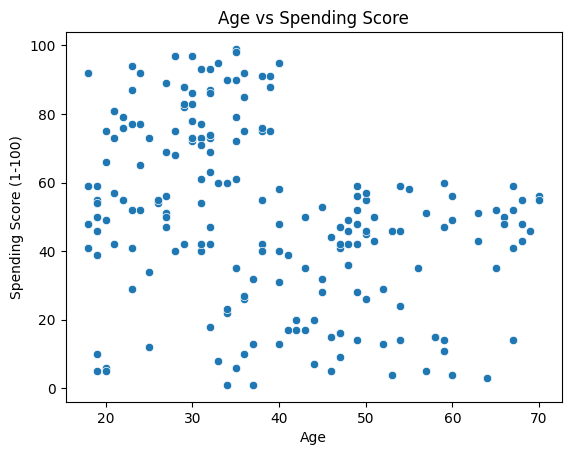

In [15]:
sns.scatterplot(
    x="Age",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Age vs Spending Score")

plt.show()

## Annual Income vs Spending Score

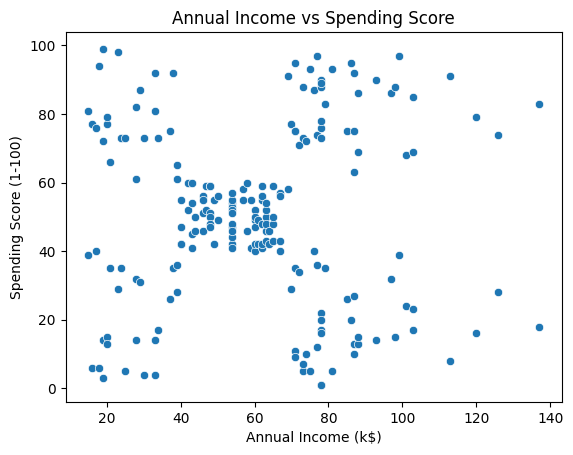

In [16]:
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title(
    "Annual Income vs Spending Score"
)

plt.show()

## Boxplots

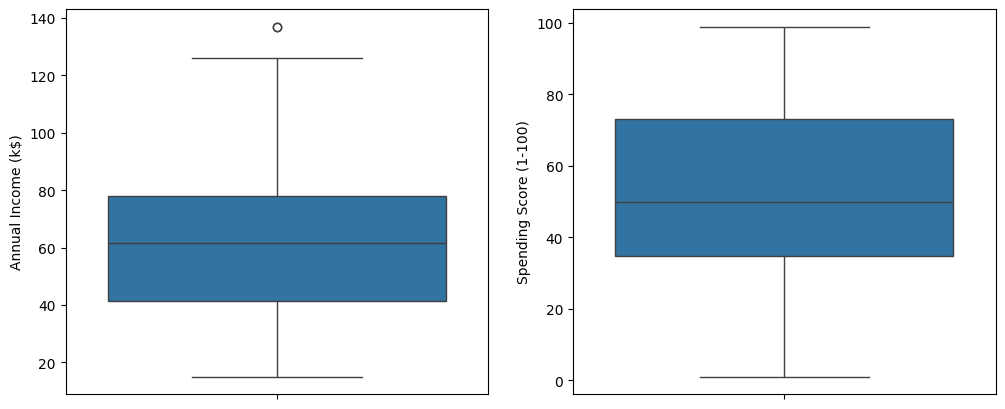

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(
    y=df["Annual Income (k$)"]
)

plt.subplot(1,2,2)

sns.boxplot(
    y=df["Spending Score (1-100)"]
)

plt.show()

## Correlation Heatmap

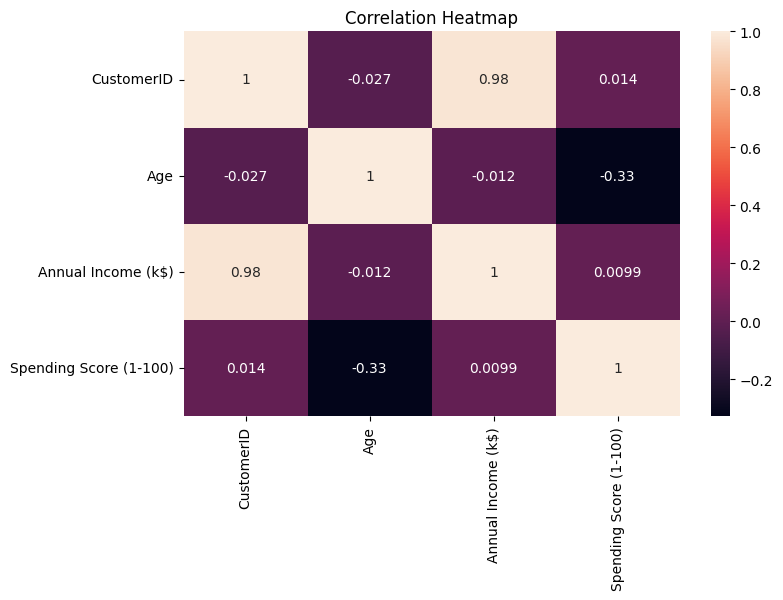

In [18]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## Pairplot Analysis

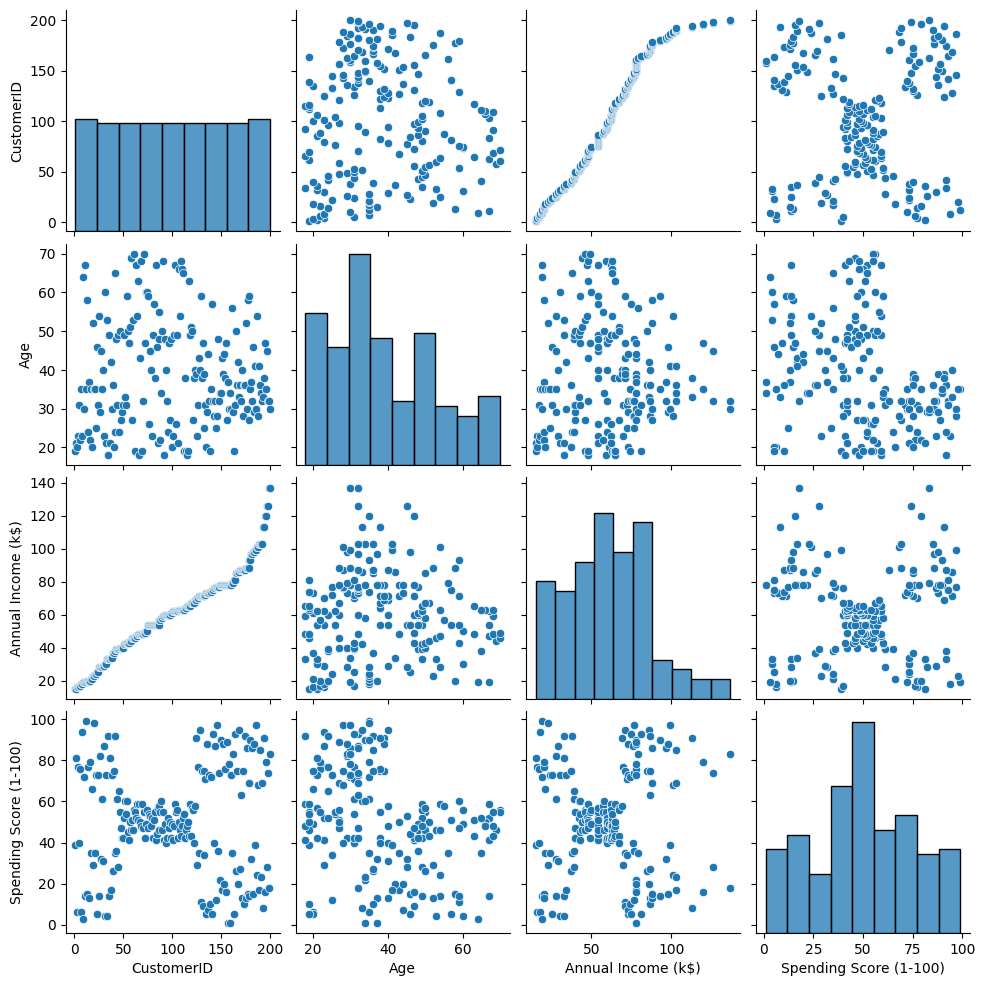

In [19]:
sns.pairplot(df)

plt.show()

## Selecting Features for Clustering

In [20]:
X = df.iloc[:, [3,4]].values

## Elbow Method

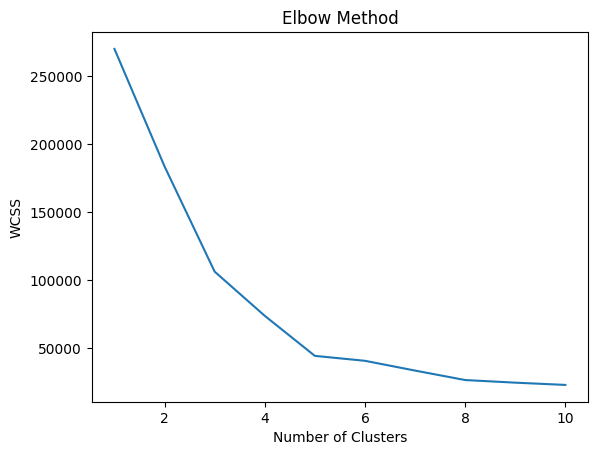

In [21]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

## Applying K-Means Clustering

In [22]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

## Customer Segments

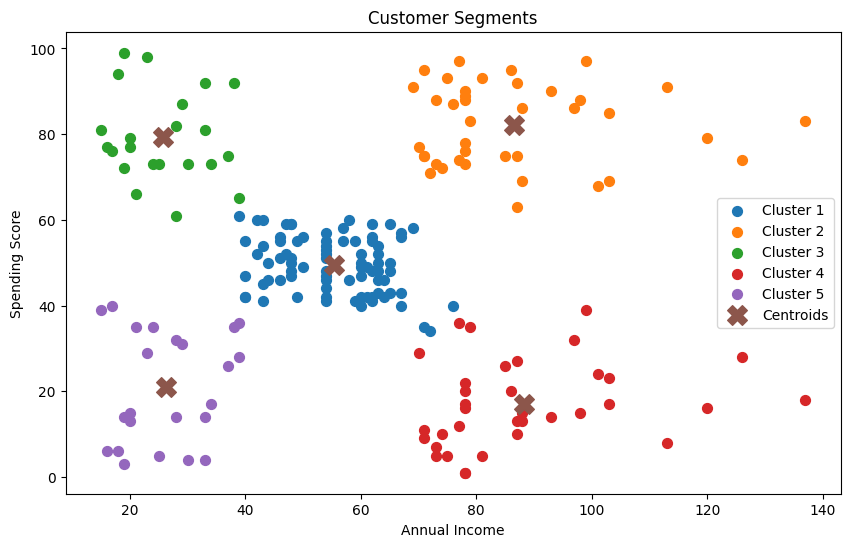

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(
    X[y_kmeans == 0, 0],
    X[y_kmeans == 0, 1],
    s=50,
    label='Cluster 1'
)

plt.scatter(
    X[y_kmeans == 1, 0],
    X[y_kmeans == 1, 1],
    s=50,
    label='Cluster 2'
)

plt.scatter(
    X[y_kmeans == 2, 0],
    X[y_kmeans == 2, 1],
    s=50,
    label='Cluster 3'
)

plt.scatter(
    X[y_kmeans == 3, 0],
    X[y_kmeans == 3, 1],
    s=50,
    label='Cluster 4'
)

plt.scatter(
    X[y_kmeans == 4, 0],
    X[y_kmeans == 4, 1],
    s=50,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.legend()

plt.show()

## Adding Cluster Labels

In [24]:
df["Cluster"] = y_kmeans

## Number of Customers in Each Cluster

In [25]:
df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

## Cluster-wise Average Values

In [26]:
df.groupby("Cluster").mean(
    numeric_only=True
)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


## Cluster Distribution

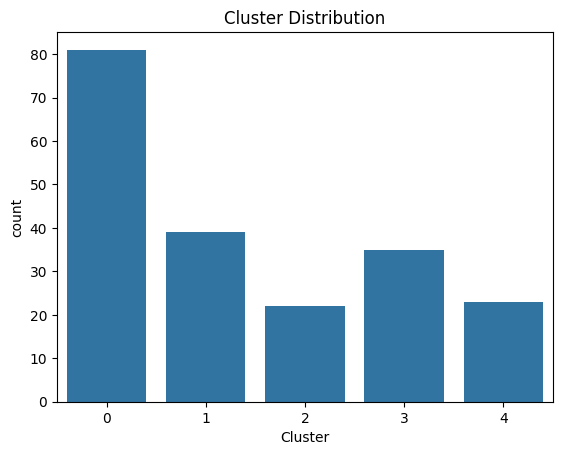

In [27]:
sns.countplot(
    x="Cluster",
    data=df
)

plt.title("Cluster Distribution")

plt.show()

# Business Recommendations

## Cluster 1
High income and high spending customers.
- Target with premium products and loyalty programs.

## Cluster 2
Low income and low spending customers.
- Offer discounts and affordable products.

## Cluster 3
High income but low spending customers.
- Use personalized marketing strategies.

## Cluster 4
Low income but high spending customers.
- Promote budget-friendly bundles.

## Cluster 5
Average customers.
- Maintain regular promotional campaigns.

# Cluster Insights

1. Customer spending behavior varies significantly.

2. High-income customers are not always high spenders.

3. K-Means clustering successfully identified customer groups.

4. Businesses can use segmentation for targeted marketing.

5. Customer segmentation helps improve customer retention and profitability.

# Final Conclusion

This project used K-Means Clustering to segment mall customers based on annual income and spending score.

The project included:
- Data cleaning
- Exploratory Data Analysis
- Correlation analysis
- Elbow method
- K-Means clustering
- Cluster visualization
- Customer segmentation
- Business recommendations

The analysis successfully identified different customer groups and demonstrated practical Machine Learning and customer analytics skills.